# RuralVet-LLM: Phase 0 + Phase 1 통합 노트북

**목표**:
1. **Phase 0** (셀 1-3): Qwen3.5-4B zero-shot 베이스라인 측정
2. **Phase 1** (셀 4-9): LoRA/QLoRA × Rank(4/8/16) 파인튜닝 + 평가
3. **분석** (셀 10): 6개 결과 비교 분석 → 1단계 우승 조합 확정

**GPU**: Colab G4 (V100 16GB)  
**실행 방법**: 셀 4의 `EXPERIMENT` 변수만 바꿔서 ex1_A ~ ex1_F 순차 실행

---

In [24]:
# ══════════════════════════════════════════
# 런타임 재시작 후 필수 초기화 (셀 0 대신 실행)
# ══════════════════════════════════════════
import gc, os, json, torch
from tqdm import tqdm
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig, DataCollatorForCompletionOnlyLM

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

BASE_DIR    = '/content/drive/MyDrive/RuralVet-LLM'
DATA_DIR    = f'{BASE_DIR}/data'
RESULTS_DIR = f'{BASE_DIR}/results'
MODEL_ID    = 'Qwen/Qwen3.5-4B'

def load_jsonl(path):
    with open(path, encoding='utf-8') as f:
        return [json.loads(l) for l in f if l.strip()]

eval_raw  = load_jsonl(f'{DATA_DIR}/eval.jsonl')
train_raw = load_jsonl(f'{DATA_DIR}/train.jsonl')
references = [
    next(m['content'] for m in s['messages'] if m['role'] == 'assistant')
    for s in eval_raw
]

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

print(f'초기화 완료 | eval={len(eval_raw)}개 | train={len(train_raw)}개')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
초기화 완료 | eval=242개 | train=2171개


## 셀 0. 환경 설치 + Drive 마운트

In [15]:
# 패키지 설치
!pip install -q transformers==5.9.0 peft==0.15.2 bitsandbytes==0.49.2 trl==0.16.1 accelerate==1.6.0
!pip install -q rouge-score bert-score datasets pandas matplotlib seaborn

# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
BASE_DIR    = '/content/drive/MyDrive/RuralVet-LLM'
DATA_DIR    = f'{BASE_DIR}/data'
RESULTS_DIR = f'{BASE_DIR}/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('설치 및 마운트 완료')
print(f'데이터 경로: {DATA_DIR}')
print(f'결과 경로: {RESULTS_DIR}')

Mounted at /content/drive
설치 및 마운트 완료
데이터 경로: /content/drive/MyDrive/RuralVet-LLM/data
결과 경로: /content/drive/MyDrive/RuralVet-LLM/results


In [4]:
import transformers
print(transformers.__version__)

5.9.0


---
# Phase 0: Zero-Shot Baseline

파인튜닝 없는 Qwen3.5-4B로 평가 데이터 성능 측정

## 셀 1. 데이터 로드

In [16]:
import json
from tqdm import tqdm

def load_jsonl(path):
    with open(path, encoding='utf-8') as f:
        return [json.loads(l) for l in f if l.strip()]

eval_raw = load_jsonl(f'{DATA_DIR}/eval.jsonl')
print(f'평가 데이터: {len(eval_raw)}개')

# 정답 추출
references = [
    next(m['content'] for m in s['messages'] if m['role'] == 'assistant')
    for s in eval_raw
]
print(f'정답 {len(references)}개 추출 완료')

평가 데이터: 242개
정답 242개 추출 완료


## 셀 2. 모델 로드 (FP16) + Zero-shot 추론

In [5]:
!pip install --upgrade transformers

  Using cached transformers-5.9.0-py3-none-any.whl.metadata (33 kB)
  Using cached huggingface_hub-1.17.0-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
Using cached transformers-5.9.0-py3-none-any.whl (10.8 MB)
Using cached huggingface_hub-1.17.0-py3-none-any.whl (671 kB)
Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.4
    Uninstalling tokenizers-0.21.4:
      Successfully uninstalled tokenizers-0.21.4
  Attempting uninstall: transformers
    Found existing installation: transformers 4.51.3
    Uninstalling transformers-4.51.3:
      Successfully uninstalled transformers-

In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = 'Qwen/Qwen3.5-4B'

print('모델 로드 중...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='auto',
    trust_remote_code=True,
)
model.eval()
print(f'모델 로드 완료 | GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB')

# Zero-shot 추론
@torch.no_grad()
def generate_batch(samples, batch_size=4, max_new_tokens=512):
    results = []
    for i in tqdm(range(0, len(samples), batch_size), desc='zero-shot 추론'):
        batch = samples[i:i + batch_size]
        prompts = [
            tokenizer.apply_chat_template(
                [m for m in s['messages'] if m['role'] != 'assistant'],
                tokenize=False,
                add_generation_prompt=True,
            )
            for s in batch
        ]
        inputs = tokenizer(
            prompts,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=2048,
        ).to(model.device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
        input_len = inputs['input_ids'].shape[1]
        for out in outputs:
            results.append(
                tokenizer.decode(out[input_len:], skip_special_tokens=True).strip()
            )
    return results

baseline_predictions = generate_batch(eval_raw, batch_size=4)
print(f'\nzero-shot 추론 완료: {len(baseline_predictions)}개')

모델 로드 중...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

모델 로드 완료 | GPU: 8.41 GB


zero-shot 추론: 100%|██████████| 61/61 [09:48<00:00,  9.65s/it]


zero-shot 추론 완료: 242개


## 셀 3. 베이스라인 평가 (ROUGE-L + BERTScore)

In [7]:
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import json

# ROUGE-L
r_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
baseline_rouge = [
    r_scorer.score(ref, pred)['rougeL'].fmeasure
    for pred, ref in zip(baseline_predictions, references)
]
baseline_rouge_mean = sum(baseline_rouge) / len(baseline_rouge)

# BERTScore
P, R, F1 = bert_score(
    baseline_predictions,
    references,
    model_type='klue/roberta-large',
    num_layers=24,
    lang='ko',
    verbose=False,
    batch_size=8,
)
baseline_bertscore_mean = F1.mean().item()

baseline_result = {
    'experiment': 'baseline',
    'model': MODEL_ID,
    'method': 'zero-shot',
    'metrics': {
        'rouge_l_mean': baseline_rouge_mean,
        'bertscore_f1_mean': baseline_bertscore_mean,
    },
}

with open(f'{RESULTS_DIR}/baseline_results.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_result, f, ensure_ascii=False, indent=2)

print('\n' + '='*55)
print(' Phase 0: Zero-Shot Baseline 결과')
print('='*55)
print(f'  ROUGE-L F1   : {baseline_rouge_mean:.4f}')
print(f'  BERTScore F1 : {baseline_bertscore_mean:.4f}')
print('='*55)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: klue/roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Phase 0: Zero-Shot Baseline 결과
  ROUGE-L F1   : 0.0897
  BERTScore F1 : 0.6503


---
# Phase 1: LoRA/QLoRA × Rank 파인튜닝

**셀 4의 EXPERIMENT만 변경** → ex1_A ~ ex1_F를 순차 실행

## 셀 4. 실험 CONFIG ← 여기만 변경

In [39]:
# ════════════════════════════════════════════════════════════
# 실험 선택: ex1_A | ex1_B | ex1_C | ex1_D | ex1_E | ex1_F
# 순서: ex1_A → ex1_B → ex1_C → ex1_D → ex1_E → ex1_F
EXPERIMENT = 'ex1_F'
# ════════════════════════════════════════════════════════════

MODEL_ID = 'Qwen/Qwen3.5-4B'

CONFIGS = {
    'ex1_A': ('lora',  4),
    'ex1_B': ('lora',  8),
    'ex1_C': ('lora', 16),
    'ex1_D': ('qlora', 4),
    'ex1_E': ('qlora', 8),
    'ex1_F': ('qlora',16),
}

METHOD, RANK = CONFIGS[EXPERIMENT]
ALPHA = 2 * RANK

# G4 GPU 최적화: V100 16GB
BATCH_SIZE      = 2       # 4 → 2 (메모리 제약)
GRAD_ACCUM      = 8       # 4 → 8 (effective batch = 16 유지)
LR              = 2e-4
EPOCHS          = 3
MAX_SEQ_LEN     = 2048
DROPOUT         = 0.05
TARGET_MODULES  = ['q_proj', 'v_proj', 'k_proj', 'o_proj']
SEED            = 42

print(f'실험: {EXPERIMENT} | 방식: {METHOD.upper()} | Rank: {RANK}')
print(f'배치: {BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM} (유효 배치)')

실험: ex1_F | 방식: QLORA | Rank: 16
배치: 2 × 8 = 16 (유효 배치)


## 셀 5. 데이터 로드 + 모델 준비

In [40]:
import gc
import torch
from datasets import Dataset
from transformers import BitsAndBytesConfig, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig, DataCollatorForCompletionOnlyLM

# 이전 모델 메모리 해제
try:
    del model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

# 학습 데이터 로드
train_raw = load_jsonl(f'{DATA_DIR}/train.jsonl')
print(f'학습 데이터: {len(train_raw)}개')

# 모델 로드
print('\n모델 로드 중...')
if METHOD == 'qlora':
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map='auto',
        trust_remote_code=True,
    )
else:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map='auto',
        trust_remote_code=True,
    )

print(f'{METHOD.upper()} 모델 로드 완료')
print(f'GPU 사용량: {torch.cuda.memory_allocated()/1e9:.2f} GB')

# LoRA 설정
if METHOD == 'qlora':
    model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

lora_config = LoraConfig(
    r=RANK,
    lora_alpha=ALPHA,
    target_modules=TARGET_MODULES,
    lora_dropout=DROPOUT,
    bias='none',
    task_type='CAUSAL_LM',
    use_rslora=True,
)

model = get_peft_model(model, lora_config)
print('\nLoRA 적용 완료')
model.print_trainable_parameters()

학습 데이터: 2171개

모델 로드 중...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

QLORA 모델 로드 완료
GPU 사용량: 7.55 GB

LoRA 적용 완료
trainable params: 3,145,728 || all params: 4,208,897,024 || trainable%: 0.0747


## 셀 6. SFT 학습

In [41]:
# 학습 데이터 포맷팅
def format_sample(example):
    return {
        'text': tokenizer.apply_chat_template(
            example['messages'],
            tokenize=False,
            add_generation_prompt=False,
        )
    }

train_dataset = Dataset.from_list([format_sample(s) for s in train_raw])

# Assistant 응답만 loss 계산
resp_template = '<|im_start|>assistant\n'
collator = DataCollatorForCompletionOnlyLM(
    response_template=resp_template,
    tokenizer=tokenizer,
)

# 저장 경로
output_dir = f'{RESULTS_DIR}/phase1/{EXPERIMENT}/adapter'
os.makedirs(output_dir, exist_ok=True)

# 학습
training_args = SFTConfig(
    output_dir=output_dir,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    optim='adamw_torch',
    fp16=True,
    seed=SEED,
    max_seq_length=MAX_SEQ_LEN,
    dataset_text_field='text',
    packing=False,
    logging_steps=50,
    save_strategy='epoch',
    report_to='none',
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collator,
)

print(f'학습 시작: {EXPERIMENT}')
trainer.train()
print('학습 완료')

# 어댑터 저장
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
print(f'어댑터 저장: {output_dir}')

Converting train dataset to ChatML:   0%|          | 0/2171 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/2171 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2171 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2171 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'pad_token_id': 248044}.


학습 시작: ex1_F


Step,Training Loss
50,2.073506
100,1.679559
150,1.438706
200,1.249190
250,1.120990
300,0.957976
350,0.880122
400,0.831794


학습 완료
어댑터 저장: /content/drive/MyDrive/RuralVet-LLM/results/phase1/ex1_F/adapter


## 셀 7. FP16 머지 → 추론 + 평가

In [42]:
# FP16 머지
print('FP16 머지 중...')
eval_model = model.merge_and_unload()
eval_model.eval()

del model
gc.collect()
torch.cuda.empty_cache()
print(f'머지 완료 | GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB')

# 추론
@torch.no_grad()
def inference_batch(samples, batch_size=4, max_new_tokens=512):
    results = []
    for i in tqdm(range(0, len(samples), batch_size), desc='평가 추론'):
        batch = samples[i:i + batch_size]
        prompts = [
            tokenizer.apply_chat_template(
                [m for m in s['messages'] if m['role'] != 'assistant'],
                tokenize=False,
                add_generation_prompt=True,
            )
            for s in batch
        ]
        inputs = tokenizer(
            prompts,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
        ).to(eval_model.device)

        outputs = eval_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
        input_len = inputs['input_ids'].shape[1]
        for out in outputs:
            results.append(
                tokenizer.decode(out[input_len:], skip_special_tokens=True).strip()
            )
    return results

predictions = inference_batch(eval_raw, batch_size=4)
print(f'\n추론 완료: {len(predictions)}개')

FP16 머지 중...


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:351: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


머지 완료 | GPU: 4.45 GB


평가 추론: 100%|██████████| 61/61 [18:42<00:00, 18.40s/it]


추론 완료: 242개


## 셀 8. ROUGE-L + BERTScore 계산

In [43]:
# 셀 8 수정
filtered = [(p, r) for p, r in zip(predictions, references) if p.strip() and r.strip()]
filtered_preds, filtered_refs = zip(*filtered)

# ROUGE-L
r_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
rouge_l_scores = [
    r_scorer.score(ref, pred)['rougeL'].fmeasure
    for pred, ref in zip(filtered_preds, filtered_refs)
]
rouge_l_mean = sum(rouge_l_scores) / len(rouge_l_scores)

# BERTScore — Phase 0과 동일 모델 사용
P, R, F1 = bert_score(
    list(filtered_preds),
    list(filtered_refs),
    model_type="klue/roberta-large",
    num_layers=24,
    lang="ko",
    use_fast_tokenizer=False,  # ← transformers 5.x 호환
    verbose=True
)
bertscore_f1_mean = F1.mean().item()

print(f'\nROUGE-L F1:    {rouge_l_mean:.4f}')
print(f'BERTScore F1:  {bertscore_f1_mean:.4f}')

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: klue/roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/8 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/4 [00:00<?, ?it/s]

done in 2.68 seconds, 90.13 sentences/sec

ROUGE-L F1:    0.1190
BERTScore F1:  0.6406


## 셀 9. 결과 저장

In [44]:
results_dict = {
    'experiment': EXPERIMENT,
    'method': METHOD,
    'rank': RANK,
    'alpha': ALPHA,
    'model': MODEL_ID,
    'eval_samples': len(eval_raw),
    'metrics': {
        'rouge_l_mean': rouge_l_mean,
        'bertscore_f1_mean': bertscore_f1_mean,
    },
}

result_path = f'{RESULTS_DIR}/phase1/{EXPERIMENT}/results.json'
os.makedirs(f'{RESULTS_DIR}/phase1/{EXPERIMENT}', exist_ok=True)
with open(result_path, 'w', encoding='utf-8') as f:
    json.dump(results_dict, f, ensure_ascii=False, indent=2)

print('='*55)
print(f' {EXPERIMENT} 완료')
print('='*55)
print(f'  방식        : {METHOD.upper()} | Rank={RANK}')
print(f'  ROUGE-L F1  : {rouge_l_mean:.4f}')
print(f'  BERTScore F1: {bertscore_f1_mean:.4f}')
print(f'  저장: {result_path}')
print('='*55)
print('\n► 다음: 셀 4에서 EXPERIMENT를 다음 값으로 변경 후 재실행')

 ex1_F 완료
  방식        : QLORA | Rank=16
  ROUGE-L F1  : 0.1190
  BERTScore F1: 0.6406
  저장: /content/drive/MyDrive/RuralVet-LLM/results/phase1/ex1_F/results.json

► 다음: 셀 4에서 EXPERIMENT를 다음 값으로 변경 후 재실행


---
# Phase 1 분석

6개 실험 모두 완료 후 실행 → 최적 조합 확정

## 셀 10. 결과 수집 및 분석

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

EXPERIMENTS = ['ex1_A', 'ex1_B', 'ex1_C', 'ex1_D', 'ex1_E', 'ex1_F']
results = {}

for exp in EXPERIMENTS:
    path = f'{RESULTS_DIR}/phase1/{exp}/results.json'
    if os.path.exists(path):
        with open(path, encoding='utf-8') as f:
            results[exp] = json.load(f)
        print(f'[로드] {exp}: ROUGE-L={results[exp]["metrics"]["rouge_l_mean"]:.4f}')
    else:
        print(f'[누락] {exp} — 아직 실행 안 됨')

if len(results) < 6:
    print('\n⚠️  6개 실험 모두 완료되지 않았습니다. 셀 4-9를 모두 실행해주세요.')
else:
    # 테이블
    rows = []
    for exp, r in results.items():
        rows.append({
            '실험': exp,
            '방식': r['method'].upper(),
            'Rank': r['rank'],
            'ROUGE-L': round(r['metrics']['rouge_l_mean'], 4),
            'BERTScore': round(r['metrics']['bertscore_f1_mean'], 4),
        })
    df = pd.DataFrame(rows).set_index('실험')
    print('\n' + '='*60)
    print(' Phase 1: 전체 결과 (ROUGE-L 내림차순)')
    print('='*60)
    display(df.sort_values('ROUGE-L', ascending=False))

    # 방식 효과
    lora_rouge = df[df['방식'] == 'LORA']['ROUGE-L'].mean()
    qlora_rouge = df[df['방식'] == 'QLORA']['ROUGE-L'].mean()
    gap = lora_rouge - qlora_rouge

    print(f'\n방식 효과:')
    print(f'  LoRA 평균 ROUGE-L:  {lora_rouge:.4f}')
    print(f'  QLoRA 평균 ROUGE-L: {qlora_rouge:.4f}')
    print(f'  양자화 노이즈 비용: {gap:+.4f}')

    # Rank 효과
    print(f'\nRank 효과 (ROUGE-L 평균):')
    for r in [4, 8, 16]:
        rank_mean = df[df['Rank'] == r]['ROUGE-L'].mean()
        print(f'  r={r}: {rank_mean:.4f}')

    # 최적 조합
    best_exp = df['ROUGE-L'].idxmax()
    best_method = df.loc[best_exp, '방식']
    best_rank = df.loc[best_exp, 'Rank']
    best_rouge = df.loc[best_exp, 'ROUGE-L']
    best_bert = df.loc[best_exp, 'BERTScore']

    print('\n' + '='*60)
    print(f' Phase 1 최종 우승 조합: {best_exp}')
    print('='*60)
    print(f'  방식:         {best_method}')
    print(f'  Rank:         {best_rank}')
    print(f'  ROUGE-L F1:   {best_rouge:.4f}')
    print(f'  BERTScore F1: {best_bert:.4f}')
    print('='*60)
    print(f'→ Phase 2: {best_exp} 모델의 어댑터로 양자화 비트 탐색')

    # Phase 2 입력값 저장
    phase2_input = {
        'phase1_winner': best_exp,
        'method': best_method.lower(),
        'rank': int(best_rank),
        'adapter_path': f'{RESULTS_DIR}/phase1/{best_exp}/adapter',
        'rouge_l_mean': best_rouge,
        'bertscore_f1_mean': best_bert,
    }
    with open(f'{RESULTS_DIR}/phase1_winner.json', 'w', encoding='utf-8') as f:
        json.dump(phase2_input, f, ensure_ascii=False, indent=2)
    print(f'\n→ Phase 2 입력 저장: {RESULTS_DIR}/phase1_winner.json')

[로드] ex1_A: ROUGE-L=0.0982
[로드] ex1_B: ROUGE-L=0.1400
[로드] ex1_C: ROUGE-L=0.1655
[로드] ex1_D: ROUGE-L=0.1151
[로드] ex1_E: ROUGE-L=0.1264
[로드] ex1_F: ROUGE-L=0.1190

 Phase 1: 전체 결과 (ROUGE-L 내림차순)


,방식,Rank,ROUGE-L,BERTScore
실험,,,,
ex1_C,LORA,16,0.1655,0.6737
ex1_B,LORA,8,0.1400,0.6651
ex1_E,QLORA,8,0.1264,0.6411
ex1_F,QLORA,16,0.1190,0.6406
ex1_D,QLORA,4,0.1151,0.6492
ex1_A,LORA,4,0.0982,0.6380



방식 효과:
  LoRA 평균 ROUGE-L:  0.1346
  QLoRA 평균 ROUGE-L: 0.1202
  양자화 노이즈 비용: +0.0144

Rank 효과 (ROUGE-L 평균):
  r=4: 0.1066
  r=8: 0.1332
  r=16: 0.1422

 Phase 1 최종 우승 조합: ex1_C
  방식:         LORA
  Rank:         16
  ROUGE-L F1:   0.1655
  BERTScore F1: 0.6737
→ Phase 2: ex1_C 모델의 어댑터로 양자화 비트 탐색

→ Phase 2 입력 저장: /content/drive/MyDrive/RuralVet-LLM/results/phase1_winner.json


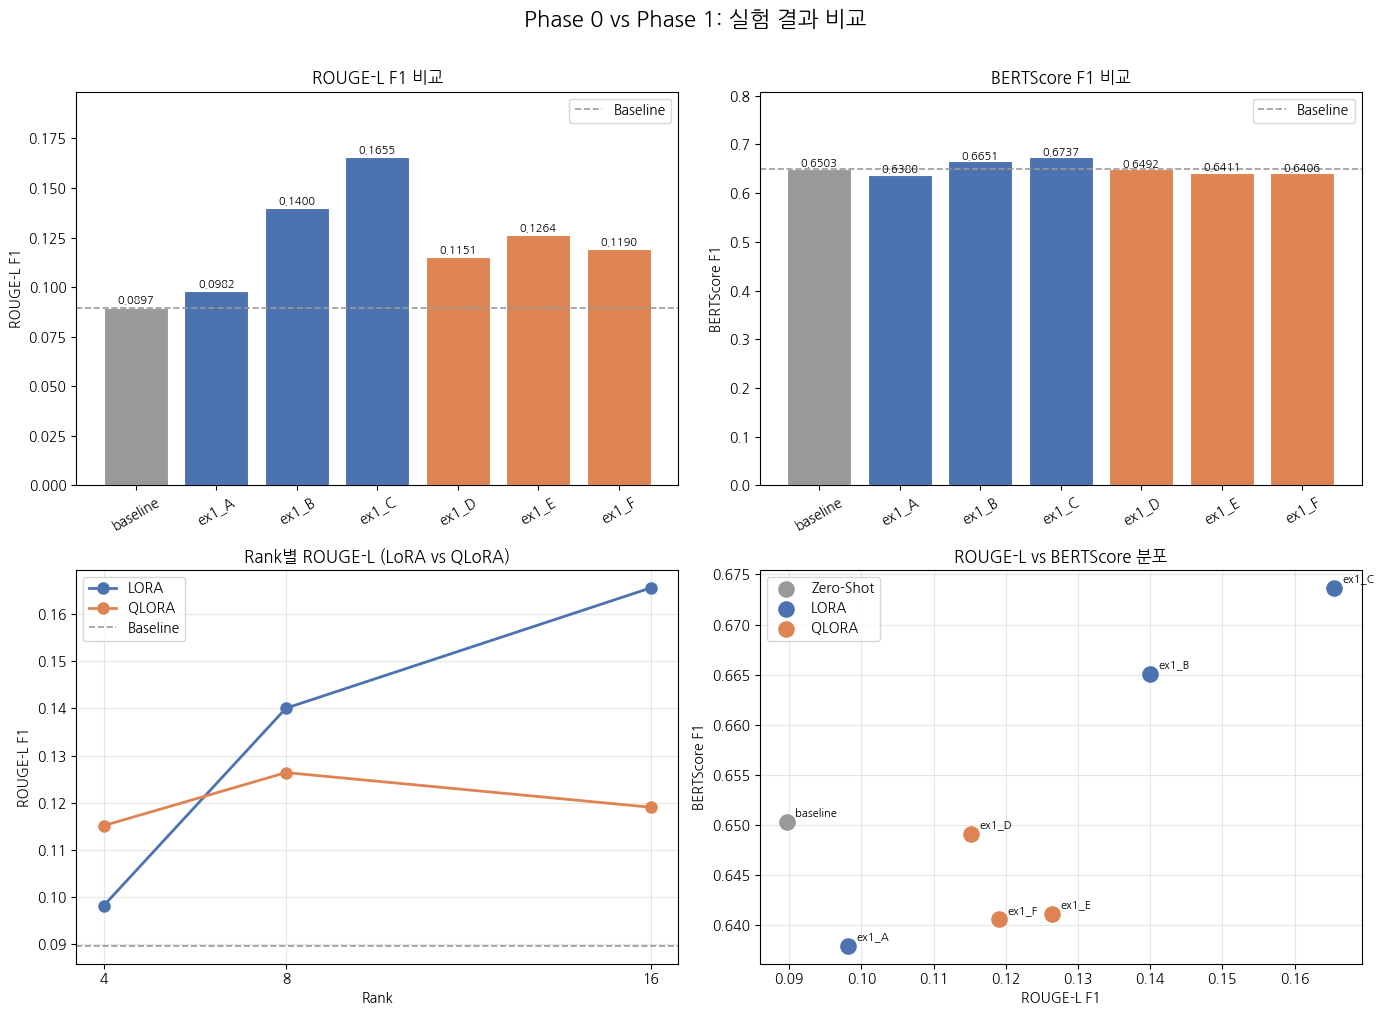

저장 완료: /content/drive/MyDrive/RuralVet-LLM/results/phase1_comparison.png


In [47]:
# ══════════════════════════════════════════
# 셀 11. 결과 시각화
# ══════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# 한글 폰트 설치 (셀 최상단)
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
fm._load_fontmanager(try_read_cache=False)

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 준비
rows = []
for exp, r in results.items():
    rows.append({
        '실험': exp,
        '방식': r['method'].upper(),
        'Rank': r['rank'],
        'ROUGE-L': r['metrics']['rouge_l_mean'],
        'BERTScore': r['metrics']['bertscore_f1_mean'],
    })

# baseline 추가
baseline_path = f'{RESULTS_DIR}/baseline_results.json'
with open(baseline_path, encoding='utf-8') as f:
    bl = json.load(f)
rows.insert(0, {
    '실험': 'baseline',
    '방식': 'Zero-Shot',
    'Rank': 0,
    'ROUGE-L': bl['metrics']['rouge_l_mean'],
    'BERTScore': bl['metrics']['bertscore_f1_mean'],
})

df_all = pd.DataFrame(rows)
colors = {'Zero-Shot': '#999999', 'LORA': '#4C72B0', 'QLORA': '#DD8452'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Phase 0 vs Phase 1: 실험 결과 비교', fontsize=16, fontweight='bold', y=1.01)

# ── 그래프 1: ROUGE-L 바 차트
ax = axes[0, 0]
bar_colors = [colors[m] for m in df_all['방식']]
bars = ax.bar(df_all['실험'], df_all['ROUGE-L'], color=bar_colors, edgecolor='white', linewidth=0.8)
ax.axhline(df_all[df_all['방식']=='Zero-Shot']['ROUGE-L'].values[0],
           color='#999999', linestyle='--', linewidth=1.2, label='Baseline')
for bar, val in zip(bars, df_all['ROUGE-L']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)
ax.set_title('ROUGE-L F1 비교')
ax.set_ylabel('ROUGE-L F1')
ax.set_ylim(0, df_all['ROUGE-L'].max() * 1.2)
ax.tick_params(axis='x', rotation=30)
ax.legend()

# ── 그래프 2: BERTScore 바 차트
ax = axes[0, 1]
bar_colors = [colors[m] for m in df_all['방식']]
bars = ax.bar(df_all['실험'], df_all['BERTScore'], color=bar_colors, edgecolor='white', linewidth=0.8)
ax.axhline(df_all[df_all['방식']=='Zero-Shot']['BERTScore'].values[0],
           color='#999999', linestyle='--', linewidth=1.2, label='Baseline')
for bar, val in zip(bars, df_all['BERTScore']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)
ax.set_title('BERTScore F1 비교')
ax.set_ylabel('BERTScore F1')
ax.set_ylim(0, df_all['BERTScore'].max() * 1.2)
ax.tick_params(axis='x', rotation=30)
ax.legend()

# ── 그래프 3: LoRA vs QLoRA × Rank (ROUGE-L)
ax = axes[1, 0]
df_p1 = df_all[df_all['방식'] != 'Zero-Shot']
for method, grp in df_p1.groupby('방식'):
    ax.plot(grp['Rank'], grp['ROUGE-L'], marker='o', label=method,
            color=colors[method], linewidth=2, markersize=8)
ax.axhline(df_all[df_all['방식']=='Zero-Shot']['ROUGE-L'].values[0],
           color='#999999', linestyle='--', linewidth=1.2, label='Baseline')
ax.set_title('Rank별 ROUGE-L (LoRA vs QLoRA)')
ax.set_xlabel('Rank')
ax.set_ylabel('ROUGE-L F1')
ax.set_xticks([4, 8, 16])
ax.legend()
ax.grid(True, alpha=0.3)

# ── 그래프 4: ROUGE-L vs BERTScore 산점도
ax = axes[1, 1]
for _, row in df_all.iterrows():
    ax.scatter(row['ROUGE-L'], row['BERTScore'],
               color=colors[row['방식']], s=120, zorder=5,
               label=row['방식'] if row['실험'] in ['baseline','ex1_A','ex1_D'] else '')
    ax.annotate(row['실험'], (row['ROUGE-L'], row['BERTScore']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_title('ROUGE-L vs BERTScore 분포')
ax.set_xlabel('ROUGE-L F1')
ax.set_ylabel('BERTScore F1')
ax.grid(True, alpha=0.3)

# 범례 중복 제거
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {RESULTS_DIR}/phase1_comparison.png')